### Using GPR to predict Flame Length

#### Import Libraries

In [ ]:
# Sys
import os
import sys
import json
sys.path.append("..")

# Data
import pandas as pd
import numpy as np
import shap
shap.initjs() 
import joblib
import importlib
from src import path
importlib.reload(path)
from src.path import PATH_DATA_FLAMELENGTH_NEW, PATH_ADD_DATA, PATH_FLAMELENGTH_FOLDER

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, KFold, cross_val_score, cross_val_predict, cross_validate, ShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct, RBF

from sklearn.metrics import mean_squared_error, r2_score

# plotting defaults
%matplotlib inline

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

#### Load and combine DatasetFlameComplet.xlsx and AdditionalData.xlsx

Rows after merging: 268
Index(['Name', 'PWR', 'J', 'S1', 'S2', 'm1', 'm2', 'mH2', 'mAzi', 'u1', 'u2',
       'Re1', 'Re2', 'PhiTot', 'PhiInt', 'Xst', 'Zst', 'rho1', 'd1', 'd2',
       'MW1', 'Z1'],
      dtype='object')
Any duplicates? True
Duplicate count: 29
Rows after dropping duplicates: 239
Saved merged data to d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\flame_length_pred\..\flame_length_pred\merged_df.xlsx


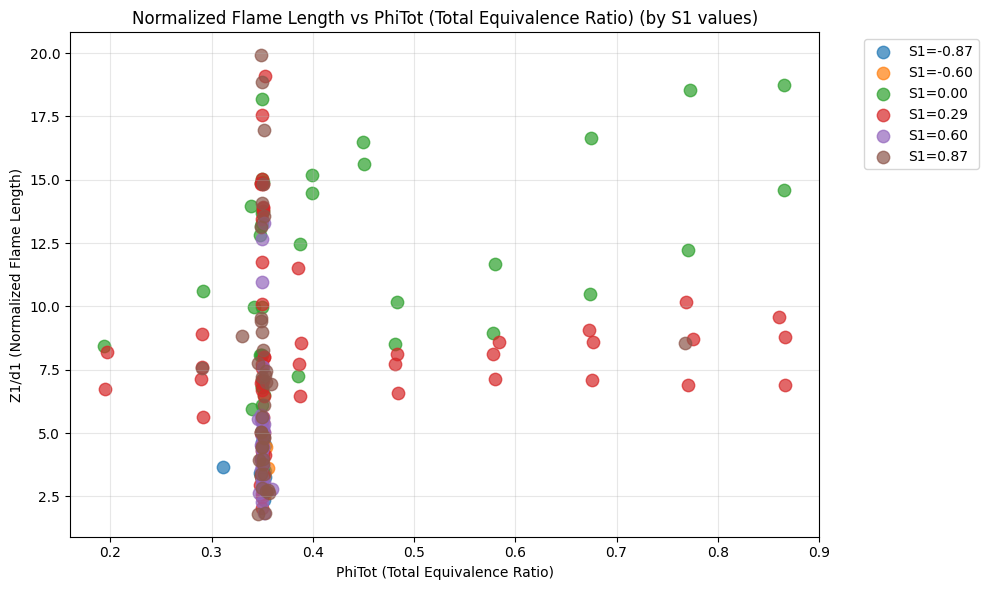

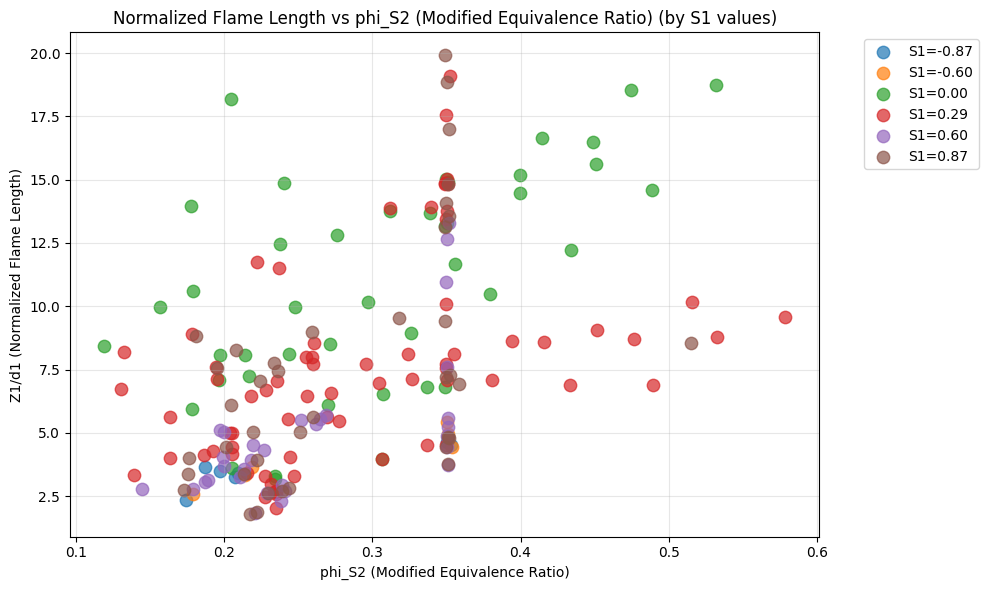

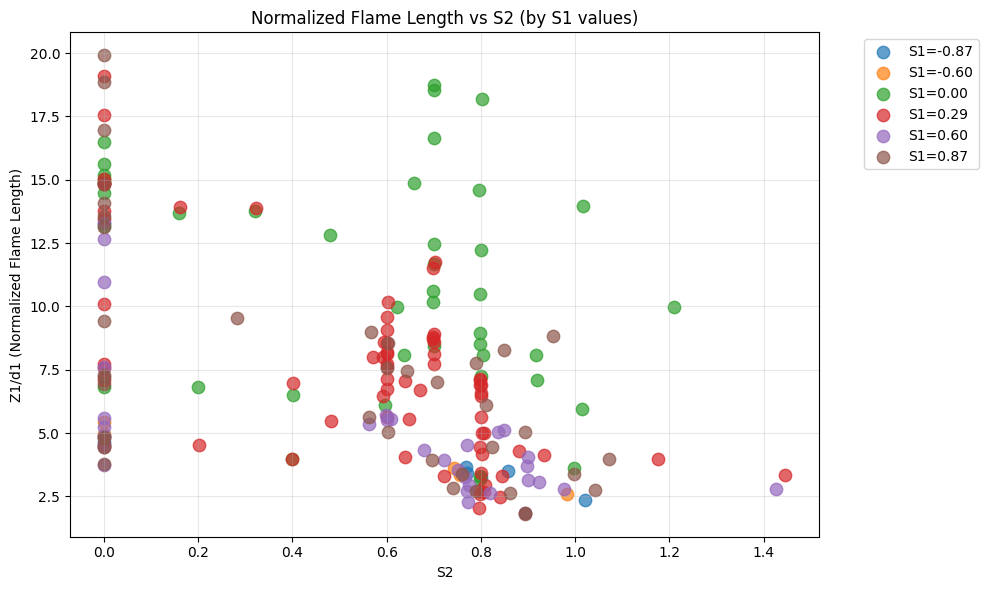

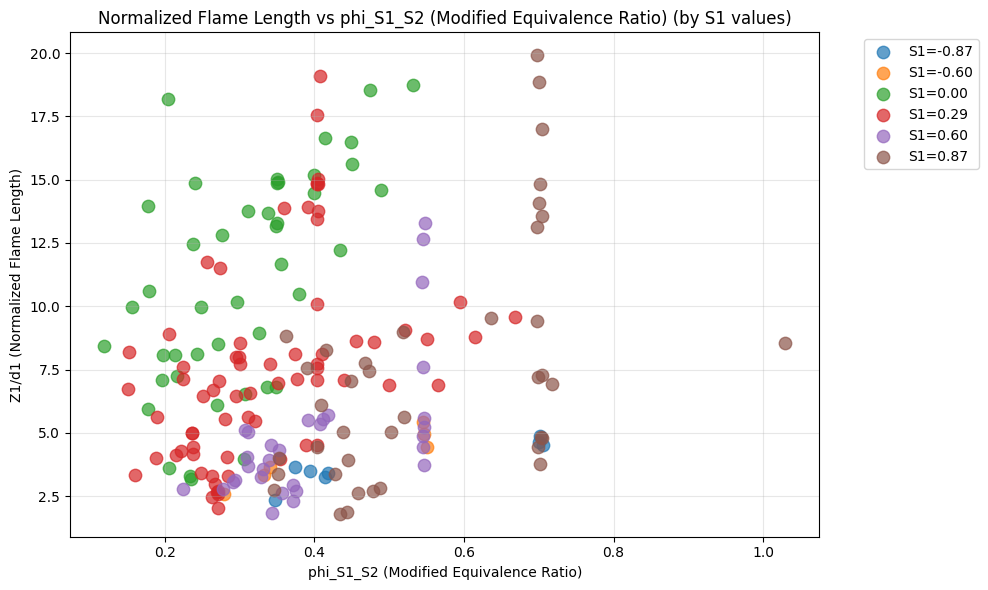

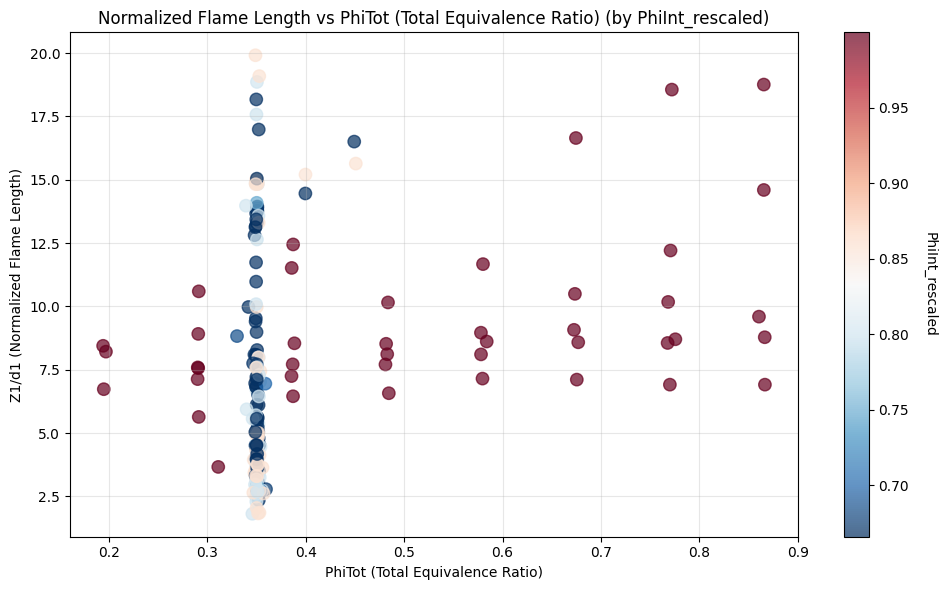

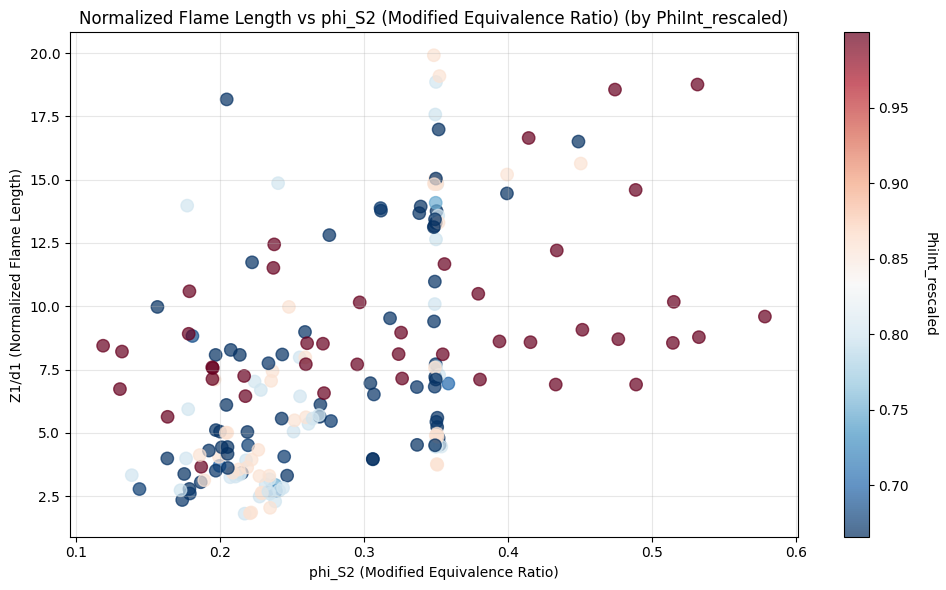

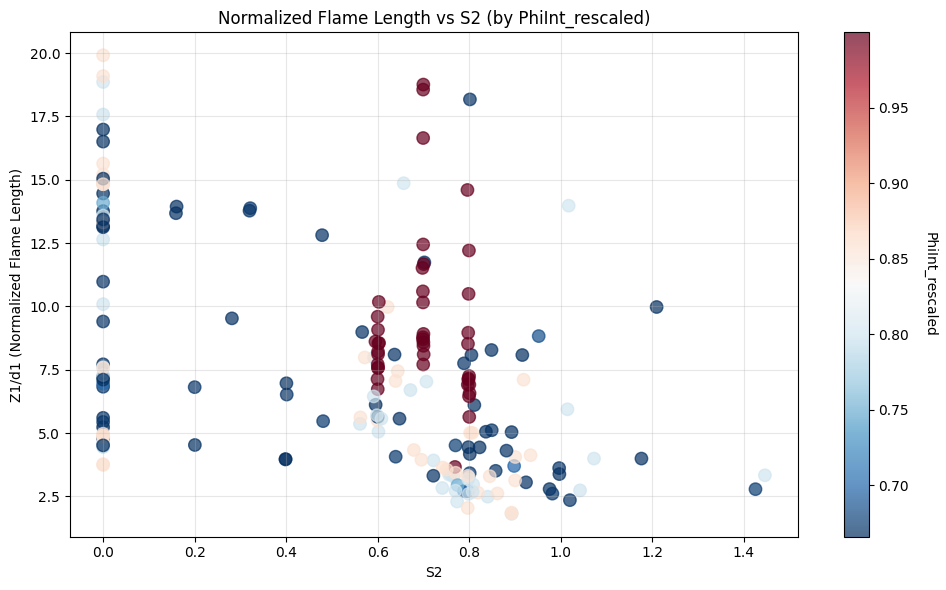

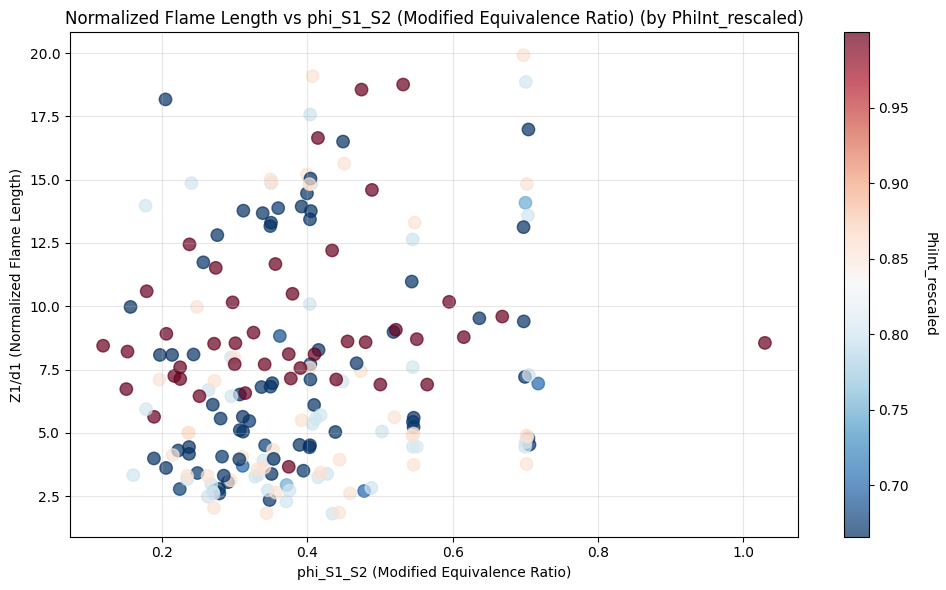

In [489]:
# Merging of Datasetv1.xlsx and Flamelength.xlsx

# Load
df_main = pd.read_excel(PATH_DATA_FLAMELENGTH_NEW)
df_additional = pd.read_excel(PATH_ADD_DATA)

# Select only columns from df_additional that exist in df_main
overlapping_cols = [col for col in df_additional.columns if col in df_main.columns]

# Concatenate vertically
df = pd.concat([
    df_main,
    df_additional[overlapping_cols]
], ignore_index=True)
print("Rows after merging:", len(df))
print(df.columns)


# # check for duplicates in merged dataframe based on Name
# col = "Name"

# print("Any duplicate IDs? ", df[col].duplicated().any())
# print("Duplicate count (extra rows):", df[col].duplicated().sum())

# # drop exact duplicates across all columns, keep first occurrence
# df = df.drop_duplicates(keep="first")
# print("Rows after dropping exact duplicates:", len(df))

# Round to a certain number of decimals before checking duplicates
tolerance_decimals = 10  # adjust as needed

cols_to_check = ['PWR', 'J', 'S1', 'S2', 'm1', 'm2', 'mH2', 'mAzi', 'u1', 'u2',
       'Re1', 'Re2', 'PhiTot', 'PhiInt', 'Xst', 'Zst', 'rho1', 'd1', 'd2',
       'MW1']

# Check duplicates with tolerance
df_rounded = df[cols_to_check].round(tolerance_decimals)
print("Any duplicates?", df_rounded.duplicated().any())
print("Duplicate count:", df_rounded.duplicated().sum())

# Drop duplicates based on rounded values
df = df[~df_rounded.duplicated(keep="first")].reset_index(drop=True)
print("Rows after dropping duplicates:", len(df))

# New flame-length data
df["Z1"] /= 1000  # convert mm to m

# Normalise flame length by nozzle diameter
df["Z1/d1"] = df["Z1"] / df["d1"]

# Filter for PWR in range [9.5, 10.5]
df = df[(df["PWR"] >= 9.5) & (df["PWR"] <= 10.5)]

# Remove Z1/d1 above 20 (outliers)
df = df[df["Z1/d1"] <= 20]

# Rescale 'phiint' -> phi/(1+phi) and insert new column immediately after the original
phi = pd.to_numeric(df["PhiInt"], errors="coerce")
phi_rescaled = phi / (1 + phi)
new_col = "PhiInt_rescaled"
idx = df.columns.get_loc("PhiInt")
df.insert(loc=idx + 1, column=new_col, value=phi_rescaled)

# Add S2/S1 ratio
# df["S2/S1"] = df["S2"] / (df["S1"] + 0.01)  # avoid division by zero

# Add deltaS
# df["DeltaS"] = np.abs(df["S2"] - df["S1"])
# df["DeltaS"] = df["S2"] - df["S1"]

# Convert Type column from Roman numerals to integers
# type_mapping = {"I": 1, "II": 2, "III": 3, "IV": 4}
# df["Type"] = df["Type"].map(type_mapping)

df["DeltaU/u1"] = np.abs(df["u2"] - df["u1"]) / (df["u1"])
df["u1/d1"] = df["u1"] / df["d1"]
df["u1_theta/d1"] = 2 * df["S1"] * df["u1"] / df["d1"]



df["1/sqrt_J"] = 1 / np.sqrt(df["J"])

df["k"] = 2 / (1 + (df["d1"] / df["d2"]) ** 2)
df["phi_S2"] = df["PhiTot"] * (1 + (df["k"] * df["S2"]) ** 2) ** (-0.5)
df["phi_S1_S2"] = df["PhiTot"] * ((1 + (2 * df["S1"]) ** 2)/(1 + (df["k"] * df["S2"]) ** 2)) ** (0.5)

# Degeneve
df["alpha_degeneve"] = 1 / (1 + df["J"] * (df["d2"] ** 2 - (df["d1"] + 0.002) ** 2) / df["d1"] ** 2) 
df["S12"] = df["d1"]/df["d2"] * df["alpha_degeneve"] * df["S1"] + (1 - df["alpha_degeneve"]) * df["S2"]


# save cleaned merged data and trained pipeline
out_xlsx = os.path.join(PATH_FLAMELENGTH_FOLDER, "merged_df.xlsx")
df.to_excel(out_xlsx, index=False)
print("Saved merged data to", out_xlsx)


# Get unique S1 values and sort them
s1_values = sorted(df["S1"].unique())
# Assign distinct colors to each S1 value
distinct_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
]
s1_colors = distinct_colors[: len(s1_values)]

# Define plots
plot_configs = [
    # ("1/sqrt_J", "1/sqrt(J)"),
    ("PhiTot", "PhiTot (Total Equivalence Ratio)"),
    ("phi_S2", "phi_S2 (Modified Equivalence Ratio)"),
    ("S2", "S2"),
    ("phi_S1_S2", "phi_S1_S2 (Modified Equivalence Ratio)"),
]

# Plots colored by S1
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    for i, s1_val in enumerate(s1_values):
        mask = df["S1"] == s1_val
        plt.scatter(
            df[mask][x_col],
            df[mask]["Z1/d1"],
            label=f"S1={s1_val:.2f}",
            color=s1_colors[i],
            alpha=0.7,
            s=80,
        )
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by S1 values)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plots colored by PhiInt_rescaled (continuous colormap)
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df[x_col],
        df["Z1/d1"],
        c=df["PhiInt_rescaled"],
        cmap="RdBu_r",
        alpha=0.7,
        s=80,
        vmin=df["PhiInt_rescaled"].min(),
        vmax=df["PhiInt_rescaled"].max(),
    )
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by PhiInt_rescaled)")
    cbar = plt.colorbar(scatter)
    cbar.set_label("PhiInt_rescaled", rotation=270, labelpad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# # Plots colored by phi_S1_S2(continuous colormap)
# for x_col, x_label in plot_configs:
#     plt.figure(figsize=(10, 6))
#     scatter = plt.scatter(
#         df[x_col],
#         df["Z1/d1"],
#         c=df["phi_S1_S2"],
#         cmap="RdBu_r",
#         alpha=0.7,
#         s=80,
#         vmin=df["phi_S1_S2"].min(),
#         vmax=0.7,
#     )
#     plt.xlabel(x_label)
#     plt.ylabel("Z1/d1 (Normalized Flame Length)")
#     plt.title(f"Normalized Flame Length vs {x_label} (by phi_S1_S2)")
#     cbar = plt.colorbar(scatter)
#     cbar.set_label("phi_S1_S2", rotation=270, labelpad=20)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# df = df[
#     np.isclose(df["PhiInt_rescaled"], 1.0, atol=0.15)
#     # & (
#     #     np.isclose(df["S1"], 0.00, atol=0.1)
#     #     | np.isclose(df["S1"], 0.29, atol=0.1)
#     #     # | np.isclose(df["S1"], 0.87, atol=0.1)
#     # )
# ]

#### Feature Selection

In [485]:
# feature and target selection

features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "PhiTot",
    "u1",
    "u2",
    'd1',
    "d2",
]

features = [
    # "S1",
    # "S2",
    # "d1",
    # "d2",
    "u1",
    # "DeltaU/u1",
    # "u1_theta/d1",
    "u2",
    # "PhiTot",
    "phi_S1_S2",
    # "S1",
    "S12",
    "PhiInt_rescaled",
]


target = "Z1/d1"  # FlameLength

X = df[features].copy()
y = df[target].copy()
print("Z1/d1 min:", y.min())
print("Z1/d1 max:", y.max())

print("Feature matrix shape:", X.shape)

Z1/d1 min: 1.8110823616880651
Z1/d1 max: 19.911393917579307
Feature matrix shape: (198, 5)


#### Archive

#### Ridge Baseline - simple linear regression

In [486]:
# Ridge baseline for comparison with GPR
# StandardScaler() normalises features to mean=0, std=1
# alpha is regularization strength
pipeline_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
# cv = ShuffleSplit(n_splits=50, test_size=0.2, random_state=1)

class FixedSplits:
    def __init__(self, splits):
        self.splits = splits

    def split(self, X=None, y=None, groups=None):
        for tr, te in self.splits:
            yield tr, te

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.splits)

# Stratified Kfold with Kmeans clustering on feature space to create pseudo-labels for stratification
# Your feature matrix
features_kmeans = [
    "PhiInt_rescaled",
    # "S1",
    # "S2",
    # "PhiTot",
    "phi_S1_S2",
    # "u1",
    # "u2",
    # 'd1',
    # "d2",
    "Z1/d1",
]


X_feat = df[features_kmeans].copy()

# 1) Standardize + cluster in feature space (deterministic with random_state)
X_scaled = StandardScaler().fit_transform(X_feat)
kmeans = KMeans(n_clusters=8, n_init=50, random_state=0)
space_labels = kmeans.fit_predict(X_scaled)

# 2) Try many seeds and keep the best 90-10 split for Ridge
seed_rows = []

for seed in range(100):
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=0.1,
        train_size=0.9,
        random_state=seed,
    )

    base_splits_try = list(sss.split(X_feat, space_labels))
    cv_try = FixedSplits(base_splits_try)

    cv_res_try = cross_validate(
        pipeline_ridge,
        X,
        y,
        cv=cv_try,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=1,
    )

    seed_rows.append(
        {
            "seed": seed,
            "train_rmse": -cv_res_try["train_score"][0],
            "test_rmse": -cv_res_try["test_score"][0],
        }
    )

seed_df = pd.DataFrame(seed_rows).sort_values("test_rmse").reset_index(drop=True)

best_seed = int(seed_df.loc[0, "seed"])
best_train_rmse = float(seed_df.loc[0, "train_rmse"])
best_test_rmse = float(seed_df.loc[0, "test_rmse"])

print(f"Best seed: {best_seed}")
print(f"Best split Train RMSE: {best_train_rmse:.5f}")
print(f"Best split Test  RMSE: {best_test_rmse:.5f}")
# print(seed_df.head(10))

# 3) Rebuild cv with the chosen seed for downstream models
sss = StratifiedShuffleSplit(
    n_splits=1, test_size=0.1, train_size=0.9, random_state=best_seed
)
base_splits = list(sss.split(X_feat, space_labels))
cv = FixedSplits(base_splits)


cv_res = cross_validate(
    pipeline_ridge,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,
)
train_rmse = -cv_res["train_score"]
test_rmse = -cv_res["test_score"]

print(f"Ridge CV Train RMSE: mean={train_rmse.mean():.5f}, std={train_rmse.std():.5f}")
print(f"Ridge CV Test  RMSE: mean={test_rmse.mean():.5f}, std={test_rmse.std():.5f}")

Best seed: 87
Best split Train RMSE: 3.16461
Best split Test  RMSE: 1.59759
Ridge CV Train RMSE: mean=3.16461, std=0.00000
Ridge CV Test  RMSE: mean=1.59759, std=0.00000


#### Linear Kernel GPR

In [218]:
# GPR with Linear kernel (DotProduct) + WhiteKernel
# DotProduct kernel represents linear relationships: k(x, x') = x · x'
kernel_linear = ConstantKernel(1.0, (1e-2, 1e2)) * DotProduct(
    sigma_0=1.0, sigma_0_bounds=(1e-6, 1e1)
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e0))
# Pipeline
gpr_linear = GaussianProcessRegressor(
    kernel=kernel_linear, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_linear = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_linear)])

# Cross-validated RMSE (5-fold) to ensure non-biasedness of train-test split
gpr_linear_scores = -cross_val_score(
    pipeline_gpr_linear, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"Linear GPR CV RMSE: mean={gpr_linear_scores.mean():.5f}, std={gpr_linear_scores.std():.5f}"
)
gpr_linear_r2 = cross_val_score(
    pipeline_gpr_linear, X, y, cv=cv, scoring="r2", n_jobs=1
)
print(
    f"Linear GPR CV R2 : mean={gpr_linear_r2.mean():.4f}, std={gpr_linear_r2.std():.4f}"
)

# Per-fold train/test diagnostics with uncertainty + coverage (Linear)
fold_metrics_linear = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_linear.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_linear.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_linear.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_linear.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_linear.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 95% CI coverage
    lower_bound_te = y_te_pred - 1.96 * y_te_std
    upper_bound_te = y_te_pred + 1.96 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_95 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_linear.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_95": coverage_te_95,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # # combined train+test plot per fold
    # plt.figure(figsize=(6, 6))
    # plt.scatter(y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color='blue', label="Train")
    # plt.fill_between(y_te_sorted,
    #                  y_te_pred_sorted - 1.96 * y_te_std_sorted,
    #                  y_te_pred_sorted + 1.96 * y_te_std_sorted,
    #                  alpha=0.25, color='green', label='Test 95% CI')
    # plt.scatter(y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color='red', label="Test")

    # max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    # plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    # plt.xlabel("True FlameLength")
    # plt.ylabel("Predicted FlameLength")
    # plt.xlim(0, max_val * 1.05)
    # plt.ylim(0, max_val * 1.05)
    # plt.legend()
    # plt.title(f"Linear GPR Train+Test (fold {i}) with 95% CI")
    # plt.grid(True, alpha=0.3)
    # plt.gca().set_aspect('equal', adjustable='box')
    # plt.tight_layout()
    # plt.show()

fold_df_linear = pd.DataFrame(fold_metrics_linear)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_linear.train_rmse.mean():.5f} ± {fold_df_linear.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_linear.test_rmse.mean():.5f} ± {fold_df_linear.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_linear.train_r2.mean():.5f} ± {fold_df_linear.train_r2.std():.5f}"
)
print(
    f"Test  R2 : {fold_df_linear.test_r2.mean():.5f} ± {fold_df_linear.test_r2.std():.5f}"
)
print(
    f"Test 95% CI coverage: {fold_df_linear.test_coverage_95.mean():.1f}% ± {fold_df_linear.test_coverage_95.std():.1f}%"
)

# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_linear.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_linear.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.96 * y_te_std.mean()  # avg interval width (±1.96σ)
    ci_widths.append(ci_width)

print(f"Avg 95% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")

# Fit on full data and diagnostics
pipeline_gpr_linear.fit(X, y)
gpr_linear_fitted = pipeline_gpr_linear.named_steps["gpr"]
print("Fitted kernel:", gpr_linear_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_linear_fitted.log_marginal_likelihood_value_)

Linear GPR CV RMSE: mean=2.98196, std=0.00000
Linear GPR CV R2 : mean=0.5241, std=0.0000
Per-fold metrics (mean ± std):
Train RMSE: 3.03568 ± nan
Test  RMSE: 2.98196 ± nan
Train R2 : 0.52905 ± nan
Test  R2 : 0.52414 ± nan
Test 95% CI coverage: 95.0% ± nan%
Avg 95% CI interval width: 12.32995 ± 0.00000
Fitted kernel: 0.341**2 * DotProduct(sigma_0=1.33e-05) + WhiteKernel(noise_level=0.485)
Log-marginal-likelihood: -220.4163685968888


#### RBF Kernel GPR

In [219]:
# GPR with RBF kernel + WhiteKernel
# RBF kernel for smooth non-linear relationships
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(
    length_scale=1.0, length_scale_bounds=(1e-3, 1e3)
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e0))

gpr_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_rbf = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_rbf)])

# Cross-validated RMSE (5-fold)
gpr_rbf_scores = -cross_val_score(
    pipeline_gpr_rbf, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"RBF GPR CV RMSE: mean={gpr_rbf_scores.mean():.5f}, std={gpr_rbf_scores.std():.5f}"
)
gpr_rbf_r2 = cross_val_score(pipeline_gpr_rbf, X, y, cv=cv, scoring="r2", n_jobs=1)
print(f"RBF GPR CV R2 : mean={gpr_rbf_r2.mean():.4f}, std={gpr_rbf_r2.std():.4f}")

# Per-fold train/test diagnostics with uncertainty + coverage (RBF)
fold_metrics_rbf = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_rbf.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_rbf.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_rbf.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_rbf.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_rbf.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 95% CI coverage
    lower_bound_te = y_te_pred - 1.96 * y_te_std
    upper_bound_te = y_te_pred + 1.96 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_95 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_rbf.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_95": coverage_te_95,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # # combined train+test plot per fold
    # plt.figure(figsize=(6, 6))
    # plt.scatter(y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color='blue', label="Train")
    # plt.fill_between(y_te_sorted,
    #                  y_te_pred_sorted - 1.96 * y_te_std_sorted,
    #                  y_te_pred_sorted + 1.96 * y_te_std_sorted,
    #                  alpha=0.25, color='green', label='Test 95% CI')
    # plt.scatter(y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color='red', label="Test")

    # max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    # plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    # plt.xlabel("True FlameLength")
    # plt.ylabel("Predicted FlameLength")
    # plt.xlim(0, max_val * 1.05)
    # plt.ylim(0, max_val * 1.05)
    # plt.legend()
    # plt.title(f"RBF GPR Train+Test (fold {i}) with 95% CI")
    # plt.grid(True, alpha=0.3)
    # plt.gca().set_aspect('equal', adjustable='box')
    # plt.tight_layout()
    # plt.show()

fold_df_rbf = pd.DataFrame(fold_metrics_rbf)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_rbf.train_rmse.mean():.5f} ± {fold_df_rbf.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_rbf.test_rmse.mean():.5f} ± {fold_df_rbf.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_rbf.train_r2.mean():.5f} ± {fold_df_rbf.train_r2.std():.5f}"
)
print(f"Test  R2 : {fold_df_rbf.test_r2.mean():.5f} ± {fold_df_rbf.test_r2.std():.5f}")
print(
    f"Test 95% CI coverage: {fold_df_rbf.test_coverage_95.mean():.1f}% ± {fold_df_rbf.test_coverage_95.std():.1f}%"
)

# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_rbf.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_rbf.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.96 * y_te_std.mean()  # avg interval width (±1.96σ)
    ci_widths.append(ci_width)

print(f"Avg 95% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")

# Fit on full data and diagnostics
pipeline_gpr_rbf.fit(X, y)
gpr_rbf_fitted = pipeline_gpr_rbf.named_steps["gpr"]
print("Fitted kernel:", gpr_rbf_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_rbf_fitted.log_marginal_likelihood_value_)

RBF GPR CV RMSE: mean=3.13777, std=0.00000
RBF GPR CV R2 : mean=0.4731, std=0.0000
Per-fold metrics (mean ± std):
Train RMSE: 1.26645 ± nan
Test  RMSE: 3.13777 ± nan
Train R2 : 0.91803 ± nan
Test  R2 : 0.47311 ± nan
Test 95% CI coverage: 87.5% ± nan%
Avg 95% CI interval width: 9.00170 ± 0.00000
Fitted kernel: 0.865**2 * RBF(length_scale=1.3) + WhiteKernel(noise_level=0.263)
Log-marginal-likelihood: -205.78848729753065


#### Linear + RBF Kernel GPR

In [369]:
# GPR with Linear + RBF kernel + WhiteKernel
# Combines linear and non-linear relationships
kernel_combined = ConstantKernel(1.0, (1e-2, 1e2)) * (
    DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-8, 1e-1))
    + RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3))
) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-4, 1e0))

gpr_combined = GaussianProcessRegressor(
    kernel=kernel_combined, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_combined = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_combined)])

# Cross-validated RMSE (5-fold)
gpr_combined_scores = -cross_val_score(
    pipeline_gpr_combined, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"Linear+RBF GPR CV RMSE: mean={gpr_combined_scores.mean():.5f}, std={gpr_combined_scores.std():.5f}"
)
gpr_combined_r2 = cross_val_score(
    pipeline_gpr_combined, X, y, cv=cv, scoring="r2", n_jobs=1
)
print(
    f"Linear+RBF GPR CV R2 : mean={gpr_combined_r2.mean():.4f}, std={gpr_combined_r2.std():.4f}"
)

# Per-fold train/test diagnostics with uncertainty + coverage
fold_metrics_combined = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_combined.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_combined.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_combined.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_combined.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_combined.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 95% CI coverage
    lower_bound_te = y_te_pred - 1.96 * y_te_std
    upper_bound_te = y_te_pred + 1.96 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_95 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_combined.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_95": coverage_te_95,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # # combined train+test plot per fold
    # plt.figure(figsize=(6, 6))
    # plt.scatter(y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color='blue', label="Train")
    # plt.fill_between(y_te_sorted,
    #                  y_te_pred_sorted - 1.96 * y_te_std_sorted,
    #                  y_te_pred_sorted + 1.96 * y_te_std_sorted,
    #                  alpha=0.25, color='green', label='Test 95% CI')
    # plt.scatter(y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color='red', label="Test")

    # max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    # plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    # plt.xlabel("True FlameLength")
    # plt.ylabel("Predicted FlameLength")
    # plt.xlim(0, max_val * 1.05)
    # plt.ylim(0, max_val * 1.05)
    # plt.legend()
    # plt.title(f"Linear+RBF GPR Train+Test (fold {i}) with 95% CI")
    # plt.grid(True, alpha=0.3)
    # plt.gca().set_aspect('equal', adjustable='box')
    # plt.tight_layout()
    # plt.show()

fold_df_combined = pd.DataFrame(fold_metrics_combined)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_combined.train_rmse.mean():.5f} ± {fold_df_combined.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_combined.test_rmse.mean():.5f} ± {fold_df_combined.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_combined.train_r2.mean():.5f} ± {fold_df_combined.train_r2.std():.5f}"
)
print(
    f"Test  R2 : {fold_df_combined.test_r2.mean():.5f} ± {fold_df_combined.test_r2.std():.5f}"
)
print(
    f"Test 95% CI coverage: {fold_df_combined.test_coverage_95.mean():.1f}% ± {fold_df_combined.test_coverage_95.std():.1f}%"
)

# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_combined.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_combined.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.96 * y_te_std.mean()  # avg interval width (±1.96σ)
    ci_widths.append(ci_width)

print(f"Avg 95% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")

# Fit on full data and diagnostics
pipeline_gpr_combined.fit(X, y)
gpr_combined_fitted = pipeline_gpr_combined.named_steps["gpr"]
print("Fitted kernel:", gpr_combined_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_combined_fitted.log_marginal_likelihood_value_)

Linear+RBF GPR CV RMSE: mean=2.15173, std=0.00000


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Linear+RBF GPR CV R2 : mean=0.5422, std=0.0000
Per-fold metrics (mean ± std):
Train RMSE: 2.02464 ± nan
Test  RMSE: 2.15173 ± nan
Train R2 : 0.80790 ± nan
Test  R2 : 0.57793 ± nan
Test 95% CI coverage: 97.5% ± nan%
Avg 95% CI interval width: 11.14356 ± 0.00000
Fitted kernel: 0.691**2 * DotProduct(sigma_0=8.72e-05) + RBF(length_scale=0.00595) + WhiteKernel(noise_level=0.0001)
Log-marginal-likelihood: -217.7638066353628


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


#### Matern Kernel GPR

d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close

Matern GPR CV RMSE: mean=1.79948, std=0.00000


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close

Matern GPR CV R2 : mean=0.7759, std=0.0000


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close

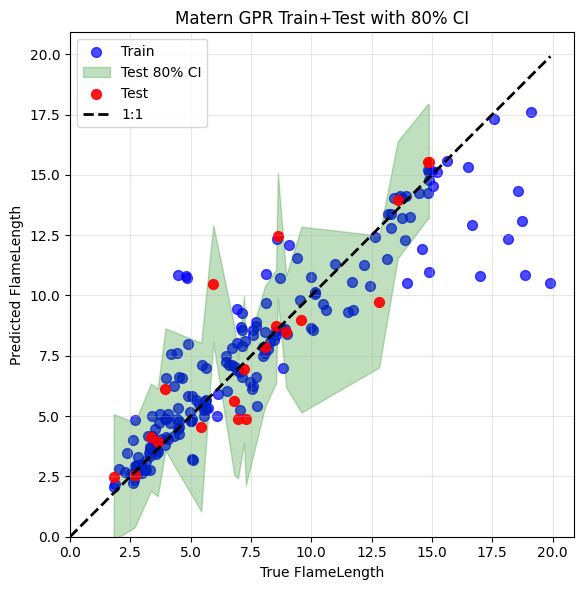

Per-fold metrics (mean ± std):
Train RMSE: 1.90410 ± nan
Test  RMSE: 1.79948 ± nan
Train R2 : 0.81828 ± nan
Test  R2 : 0.77586 ± nan
Test 80% CI coverage: 85.0% ± nan%
Avg 80% CI interval width: 5.26069 ± 0.00000
Fitted kernel: 1.44**2 * Matern(length_scale=[1.24e+04, 1, 1.31, 1, 2.88], nu=2.5) + WhiteKernel(noise_level=0.12)
Log-marginal-likelihood: -260.1088460448574


d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\rozanoff_env\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close

In [487]:
# GPR with Matern (ARD) + WhiteKernel; use ARD by passing a vector length_scale
kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e0, 1e8), nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(5e-2, 1.2e-1))

gpr_matern = GaussianProcessRegressor(
    kernel=kernel_matern, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_matern = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_matern)])

# Cross-validated RMSE (5-fold)
gpr_matern_scores = -cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"Matern GPR CV RMSE: mean={gpr_matern_scores.mean():.5f}, std={gpr_matern_scores.std():.5f}"
)
gpr_matern_r2 = cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="r2", n_jobs=1
)
print(
    f"Matern GPR CV R2 : mean={gpr_matern_r2.mean():.4f}, std={gpr_matern_r2.std():.4f}"
)

# Per-fold train/test diagnostics
fold_metrics_matern = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_matern.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 80% CI coverage
    lower_bound_te = y_te_pred - 1.28 * y_te_std
    upper_bound_te = y_te_pred + 1.28 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_80 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_matern.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_80": coverage_te_80,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]
    y_tr_std_sorted = y_tr_std[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # combined train+test plot per fold
    plt.figure(figsize=(6, 6))
    # train CI + points
    plt.scatter(
        y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color="blue", label="Train"
    )
    # test CI + points
    plt.fill_between(
        y_te_sorted,
        y_te_pred_sorted - 1.28 * y_te_std_sorted,
        y_te_pred_sorted + 1.28 * y_te_std_sorted,
        alpha=0.25,
        color="green",
        label="Test 80% CI",
    )
    plt.scatter(
        y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color="red", label="Test"
    )

    max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    plt.xlabel("True FlameLength")
    plt.ylabel("Predicted FlameLength")
    plt.xlim(0, max_val * 1.05)
    plt.ylim(0, max_val * 1.05)
    plt.legend()
    # plt.title(f"Matern GPR Train+Test (fold {i}) with 80% CI")
    plt.title("Matern GPR Train+Test with 80% CI")
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

fold_df_matern = pd.DataFrame(fold_metrics_matern)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_matern.train_rmse.mean():.5f} ± {fold_df_matern.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_matern.test_rmse.mean():.5f} ± {fold_df_matern.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_matern.train_r2.mean():.5f} ± {fold_df_matern.train_r2.std():.5f}"
)
print(
    f"Test  R2 : {fold_df_matern.test_r2.mean():.5f} ± {fold_df_matern.test_r2.std():.5f}"
)
print(
    f"Test 80% CI coverage: {fold_df_matern.test_coverage_80.mean():.1f}% ± {fold_df_matern.test_coverage_80.std():.1f}%"
)


# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.28 * y_te_std.mean()  # avg interval width (±1.28σ)
    ci_widths.append(ci_width)

print(f"Avg 80% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")


# Fit on full data and diagnostics
pipeline_gpr_matern.fit(X, y)
gpr_matern_fitted = pipeline_gpr_matern.named_steps["gpr"]
print("Fitted kernel:", gpr_matern_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_matern_fitted.log_marginal_likelihood_value_)



#### File saving

In [488]:


model_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "gpr_pipeline_matern.joblib")
joblib.dump(pipeline_gpr_matern, model_path)
print("Saved Matern GPR pipeline to", model_path)

Saved Matern GPR pipeline to d:\Users\fengchonghui\Documents\chong hui\centralesupelec\Rozanoff\rozanoff_2025\flame_length_pred\..\flame_length_pred\gpr_pipeline_matern.joblib


#### Analysis Matern

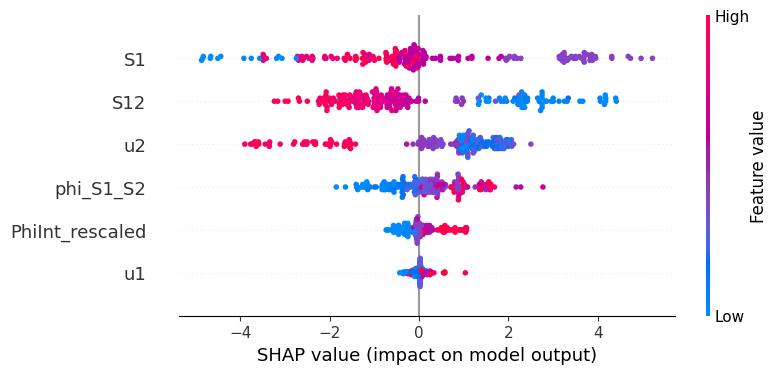

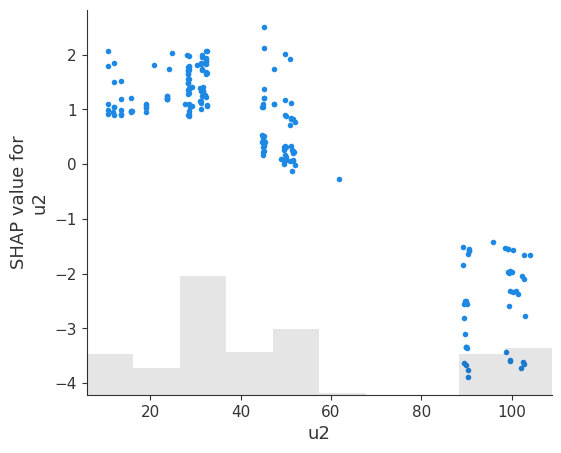

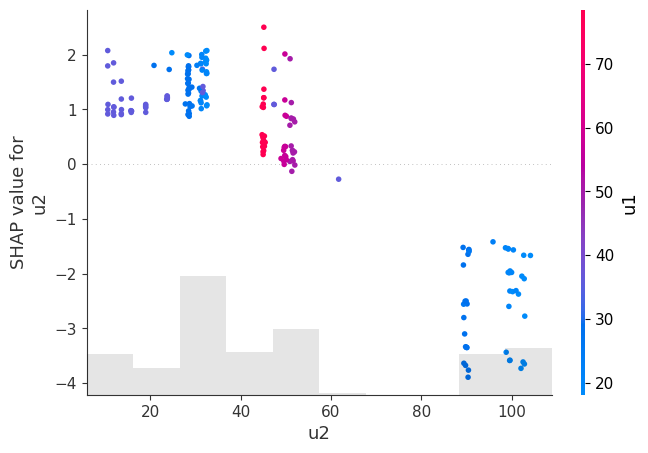

In [469]:
# model = callable that predicts with the full pipeline
model = lambda X_in: pipeline_gpr_matern.predict(pd.DataFrame(X_in, columns=X.columns))

# use DataFrames to preserve feature names
X_bg_df = X.sample(n=min(50, len(X)), random_state=42)
X_explain_df = X.sample(n=min(200, len(X)), random_state=24)

explainer = shap.Explainer(model, X_bg_df)  # KernelExplainer under the hood
shap_values = explainer(X_explain_df)

shap.plots.beeswarm(shap_values, max_display=20)
# shap.plots.bar(shap_values)
# shap.plots.scatter(shap_values[:, "S2"])
shap.plots.scatter(shap_values[:, "u2"])

# Dependence plots
shap.plots.scatter(shap_values[:, "u2"], color=shap_values[:, "u1"])
# shap.plots.scatter(shap_values[:, "u2"], color=shap_values[:, "d2"])
# shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "S1"])
# shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "d2"])
# shap.plots.scatter(shap_values[:, "S2"], color=shap_values[:, "u1"])

In [ ]:
shap.plots.force(shap_values)